# Calibrated viscous damping per DOF — plots in degrees

Reproduces the three damping figures from `damping_summary_all_dofs.xlsx`:

1. Calibrated **viscous** damping per DOF
2. Calibrated damping **including radiation damping** (total)  *(Figure 3.8)*
3. Total damping with **per-construction + global averages** *(Figure 3.9)*

**Unit conversion (rad → deg).** Heave is translational and stays in `kN/(m/s)` /
`kN/(m/s)²`. Pitch and roll are rotational and are converted from `rad` to `deg`:

- linear:    $B_\ell^{[\deg]} = B_\ell^{[\mathrm{rad}]}\cdot(\pi/180)$ → `kNm/(deg/s)`
- quadratic: $B_q^{[\deg]} = B_q^{[\mathrm{rad}]}\cdot(\pi/180)^2$ → `kNm/(deg/s)²`

**Point labels.** Each individual point is annotated with its initial decay amplitude
(`intial amplitude` column). This is a *motion* amplitude, already expressed in
**degrees** (pitch/roll) or **metres** (heave) in the raw data — so it is **not**
rescaled by π/180. Toggle with `ANNOTATE`.


In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

XLSX = "damping_summary_all_dofs.xlsx"   # adjust path if needed

ind  = pd.read_excel(XLSX, sheet_name="individual_results_all_dofs")
mpc  = pd.read_excel(XLSX, sheet_name="mean_per_construction_dof")
glob = pd.read_excel(XLSX, sheet_name="overall_mean_per_dof")


## Apply the rad → deg conversion (pitch & roll only)

In [66]:
DEG  = np.pi / 180.0          # linear   coefficient factor
DEG2 = (np.pi / 180.0) ** 2   # quadratic coefficient factor
ROT  = {"pitch", "roll"}      # rotational DOFs; heave is left unchanged

def convert(df, lin_cols, quad_cols):
    "Multiply rotational-DOF rows by the rad->deg factors."
    df = df.copy()
    rot = df["dof"].isin(ROT)
    for c in lin_cols:
        df.loc[rot, c] *= DEG
    for c in quad_cols:
        df.loc[rot, c] *= DEG2
    return df

ind = convert(ind,
              ["linear_damping", "total_linear_damping"],
              ["quadratic_damping", "total_quadratic_damping"])
mpc = convert(mpc,
              ["mean_viscous_linear_damping", "mean_total_linear_damping"],
              ["mean_viscous_quadratic_damping", "mean_total_quadratic_damping"])
glob = convert(glob,
               ["viscous_linear_damping", "total_linear_damping"],
               ["viscous_quadratic_damping", "total_quadratic_damping"])


## Plot configuration

In [67]:
DOFS = ["heave", "pitch", "roll"]
CON  = ["spring", "fixedwith", "fixedwithout"]
COL  = {"spring": "tab:blue", "fixedwith": "tab:orange", "fixedwithout": "tab:green"}
LAB  = {"spring": "Spring with deck",
        "fixedwith": "Fixed with deck",
        "fixedwithout": "Fixed without deck"}

plt.rcParams.update({"font.size": 11})

ANNOTATE = True   # set False to hide the initial-amplitude labels

def units(dof):
    "Axis unit labels: heave translational, pitch/roll in degrees."
    if dof == "heave":
        return "kN/(m/s)", "kN/(m/s)$^2$"
    return "kNm/(deg/s)", "kNm/(deg/s)$^2$"

def annotate_amplitude(ax, sub, xcol, ycol, fontsize=8):
    """Label each point with its initial amplitude. Labels that would overlap
    are stacked downward (a thin leader line links them to their point).
    Call this AFTER the axis limits are fixed."""
    if not ANNOTATE or len(sub) == 0:
        return
    fig = ax.figure
    fig.canvas.draw()                       # realise the data->pixel transform

    disp = ax.transData.transform(sub[[xcol, ycol]].to_numpy())  # pixel coords
    order = np.argsort(-disp[:, 1])         # place highest points first
    rows  = sub.iloc[order]
    dxy   = disp[order]

    y0 = ax.transAxes.transform((0, 0))[1]  # axis bottom in pixels (floor)
    line_h = fontsize * 1.9                  # vertical step between labels (px)
    char_w = fontsize * 0.60                 # approx character width (px)
    base_dx, base_dy = 6.0, 4.0
    placed = []                              # (x_left, x_right, y_center) in px

    for (px, py), (_, r) in zip(dxy, rows.iterrows()):
        unit = "m" if r["dof"] == "heave" else "\u00b0"
        txt  = f"{r['intial amplitude']:.1f}{unit}"
        w    = char_w * len(txt)
        lx   = px + base_dx
        ly   = py + base_dy
        moved = False
        # push down while it would clash with an already-placed label
        while any((lx < bx1 and lx + w > bx0) and abs(ly - by) < line_h
                  for bx0, bx1, by in placed):
            ly -= line_h
            moved = True
        # if we've dropped below the axis, restack upward from the point instead
        if ly < y0 + 2:
            ly = py + base_dy
            while any((lx < bx1 and lx + w > bx0) and abs(ly - by) < line_h
                      for bx0, bx1, by in placed):
                ly += line_h
                moved = True
        placed.append((lx, lx + w, ly))
        ax.annotate(txt, (r[xcol], r[ycol]),
                    textcoords="offset pixels", xytext=(lx - px, ly - py),
                    fontsize=fontsize, color="0.15",
                    arrowprops=(dict(arrowstyle="-", lw=0.4, color="0.55",
                                     shrinkA=0, shrinkB=2) if moved else None))


## Figure 1 — Calibrated viscous damping values per DOF

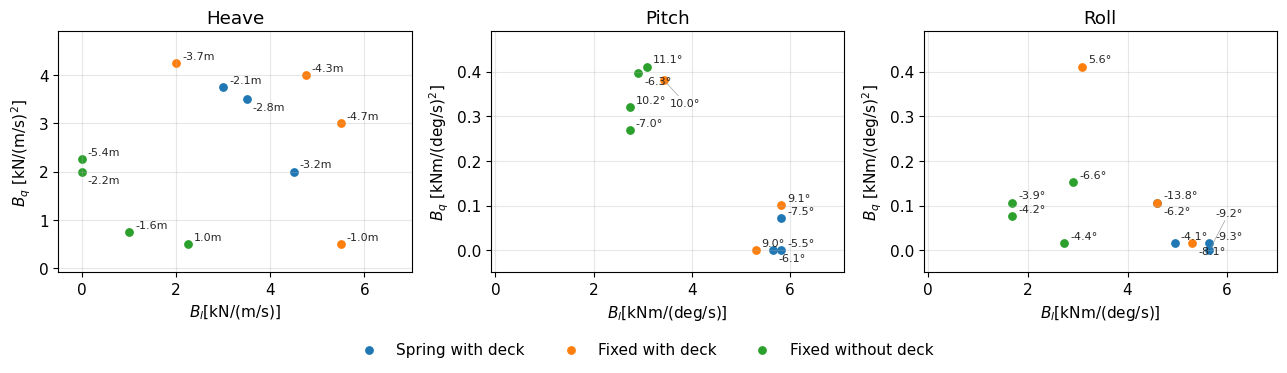

In [86]:
def plot_individual(df, xcol, ycol, prefix=""):
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
    for ax, dof in zip(axes, DOFS):
        sub = df[df["dof"] == dof]
        for c in CON:
            s = sub[sub["construction"] == c]
            ax.scatter(s[xcol], s[ycol], color=COL[c], label=LAB[c], s=28)
        lx, ly = units(dof)
        ax.set_title(dof.capitalize())
        ax.set_xlabel(f"$B_l$[{lx}]")
        ax.set_ylabel(f"$B_q$ [{ly}]")
        ax.grid(True, alpha=0.3)
        if dof =='heave':
            ax.set_xlim(left=-0.5, right=7)
            ax.set_ylim(bottom=-0.09, top=4.9)
        if dof =='pitch':
            ax.set_xlim(left=-0.09, right=7.1)
            ax.set_ylim(bottom=-0.05, top=0.49)
        if dof =='roll':
            ax.set_xlim(left=-0.09, right=7)
            ax.set_ylim(bottom=-0.05, top=0.49)
        annotate_amplitude(ax, sub, xcol, ycol)   # after limits are set
    h, l = axes[0].get_legend_handles_labels()
    fig.legend(h, l, loc="lower center", ncol=3, frameon=False,
               bbox_to_anchor=(0.5, -0.05))
    fig.tight_layout(rect=[0, 0.04, 1, 1])
    return fig

plot_individual(ind, "linear_damping", "quadratic_damping")
plt.show()


## Figure 2 (3.8) — Including radiation damping (total)

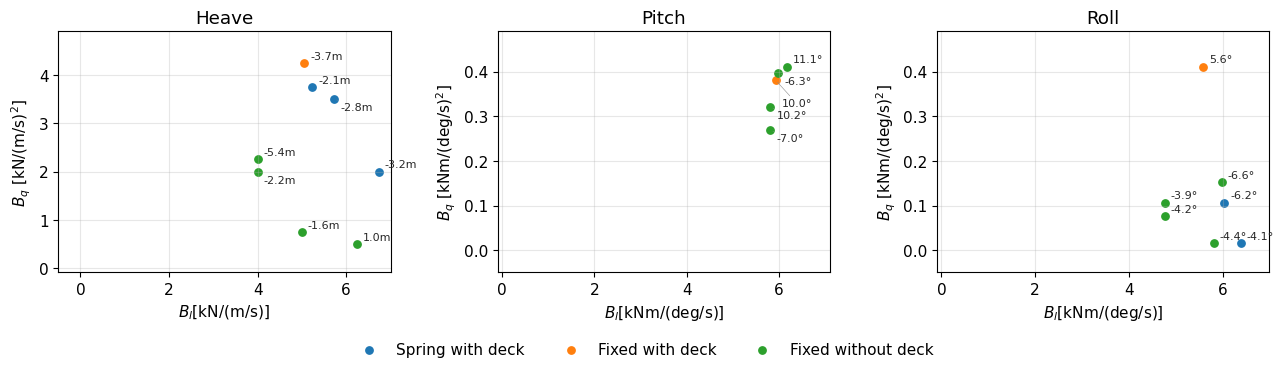

In [ ]:

def plot_individual(df, xcol, ycol, prefix=""):
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
    for ax, dof in zip(axes, DOFS):
        sub = df[df["dof"] == dof]
        for c in CON:
            s = sub[sub["construction"] == c]
            ax.scatter(s[xcol], s[ycol], color=COL[c], label=LAB[c], s=28)
        lx, ly = units(dof)
        ax.set_title(dof.capitalize())
        ax.set_xlabel(f"$B_l$[{lx}]")
        ax.set_ylabel(f"$B_q$ [{ly}]")
        ax.grid(True, alpha=0.3)
        if dof =='heave':
            ax.set_xlim(left=-0.5, right=7)
            ax.set_ylim(bottom=-0.09, top=4.9)
        if dof =='pitch':
            ax.set_xlim(left=-0.09, right=7.1)
            ax.set_ylim(bottom=-0.05, top=0.49)
        if dof =='roll':
            ax.set_xlim(left=-0.09, right=7)
            ax.set_ylim(bottom=-0.05, top=0.49)
        annotate_amplitude(ax, sub, xcol, ycol)   # after limits are set
    h, l = axes[0].get_legend_handles_labels()
    fig.legend(h, l, loc="lower center", ncol=3, frameon=False,
               bbox_to_anchor=(0.5, -0.05))
    fig.tight_layout(rect=[0, 0.04, 1, 1])
    return fig

plot_individual(ind, "total_linear_damping", "total_quadratic_damping",
                prefix="total ")
plt.show()


## Figure 3 (3.9) — Total damping with per-construction and global averages

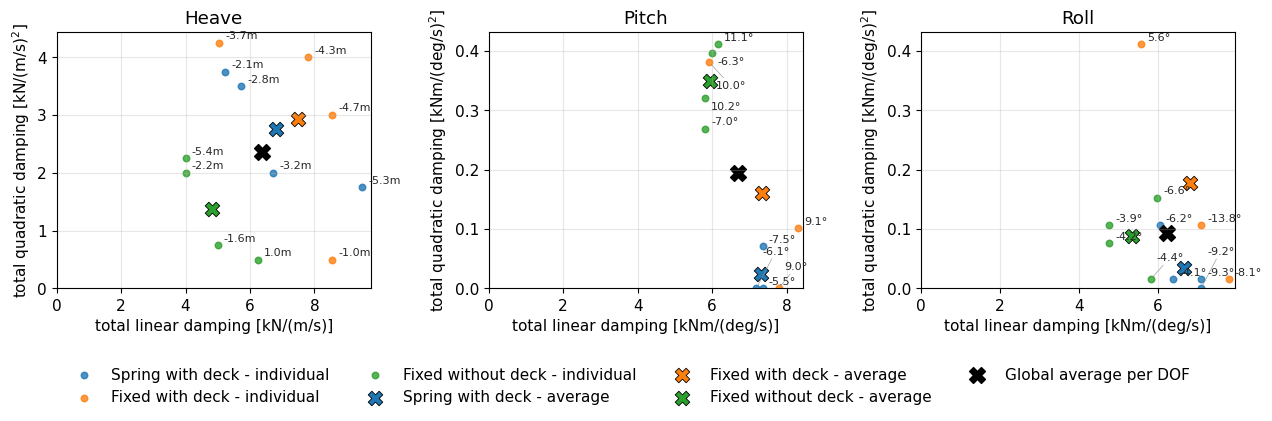

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, dof in zip(axes, DOFS):
    # individual tests (small dots)
    sub = ind[ind["dof"] == dof]
    for c in CON:
        s = sub[sub["construction"] == c]
        ax.scatter(s["total_linear_damping"], s["total_quadratic_damping"],
                   color=COL[c], s=22, alpha=0.8,
                   label=f"{LAB[c]} - individual")
    # per-construction averages (coloured X)
    m = mpc[mpc["dof"] == dof]
    for c in CON:
        r = m[m["construction"] == c]
        ax.scatter(r["mean_total_linear_damping"], r["mean_total_quadratic_damping"],
                   color=COL[c], marker="X", s=110, edgecolor="k", linewidth=0.6,
                   label=f"{LAB[c]} - average")
    # global average per DOF (black X)
    g = glob[glob["dof"] == dof]
    ax.scatter(g["total_linear_damping"], g["total_quadratic_damping"],
               color="black", marker="X", s=130, label="Global average per DOF")
    lx, ly = units(dof)
    ax.set_title(dof.capitalize())
    ax.set_xlabel(f"total linear damping [{lx}]")
    ax.set_ylabel(f"total quadratic damping [{ly}]")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    annotate_amplitude(ax, sub, "total_linear_damping", "total_quadratic_damping")

h, l = axes[0].get_legend_handles_labels()
uniq = dict(zip(l, h))
fig.legend(uniq.values(), uniq.keys(), loc="lower center", ncol=4,
           frameon=False, bbox_to_anchor=(0.5, -0.12))
fig.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()
